<h1 style="color:magenta;">NSL - Exercises 03 </h1>

### 19/3/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 1
Option pricing was analyzed using Monte Carlo simulations based on the Black-Scholes model. An option is a financial contract that grants the holder the right, but not the obligation, to buy (call) or sell (put) an underlying asset at a fixed strike price $K$ by a specific expiration date $T$.

The intrinsic value of the options at maturity is given by:
- Call: $\max(0, S(T) - K)$
- Put: $\max(0, K - S(T))$

where $S(T)$ denotes the asset price at time $T$. To determine the current value, the profit must be discounted by the factor $e^{-rT}$. This exponential term accounts for the risk-free interest rate $r$, reflecting the fact that the value of money is not constant over time.

It is assumed that the asset price evolution follows a Geometric Brownian Motion (GBM):$$S(t) = S(0) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right]$$ 
- $r=0.1$ is the risk-free interest rate
- $\sigma=0.25$ is the volatility of the asset
- $W(t)$ is a standard Wiener process with increments $dW \sim \mathcal{N}(0, t)$

The option price was estimated using Monte Carlo simulations with $N=100$ blocks and a total of $M=10^5$ realizations of the stochastic process.

1. **Direct Sampling of the final price**: the final value $S(T)$ was generated directly using the closed-form solution:$$S(T) = S(0) \exp \left[ \left( r - \frac{1}{2}\sigma^2 \right) T + \sigma Z \sqrt{T} \right]$$where $Z \sim \mathcal{N}(0, 1)$.
2. **Discretized Path Sampling** the time interval $[0, T]$ was divided into $10^2$ sub-intervals, simulating the incremental evolution of the price:$$S(t_{i+1}) = S(t_i) \exp \left[ \left( r - \frac{1}{2}\sigma^2 \right) \Delta t + \sigma Z_{i+1} \sqrt{\Delta t} \right]$$where $\Delta t = t_{i+1} - t_i$. This approximation captures the temporal dynamics of the price, which is particularly useful for path-dependent options.

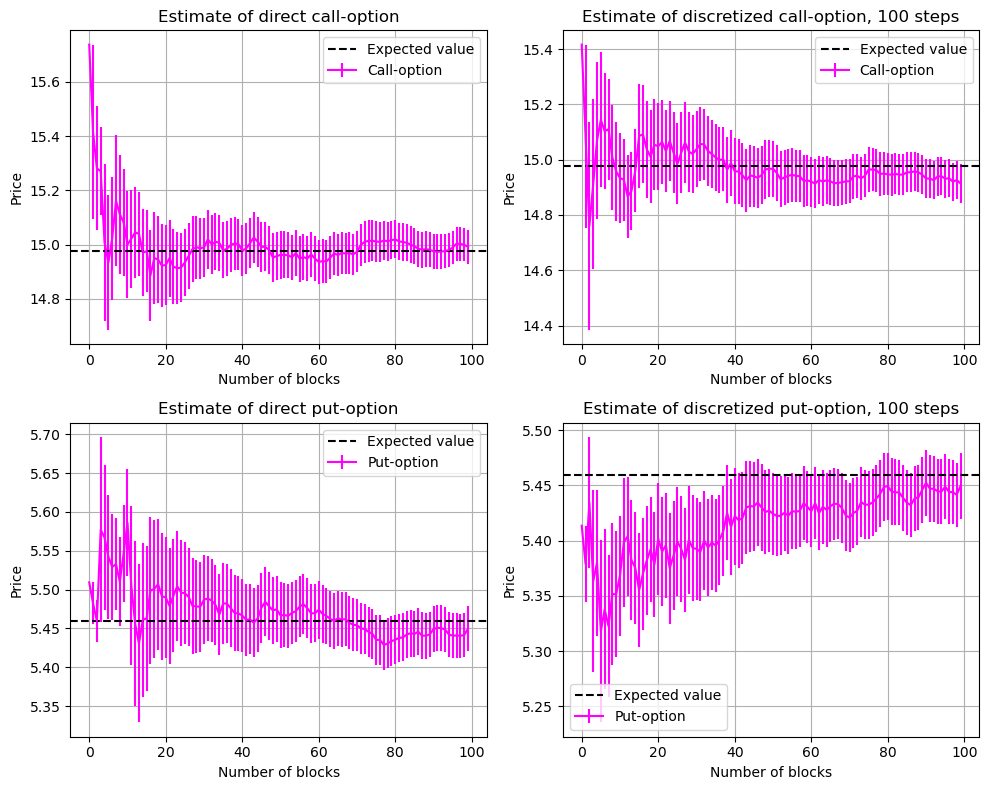

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

data_call_dir = np.loadtxt("Ex/output_direct_C.dat")
data_put_dir = np.loadtxt("Ex/output_direct_P.dat")
data_call_discr = np.loadtxt("Ex/out_discretized_C.dat")
data_put_discr = np.loadtxt("Ex/out_discretized_P.dat")

x = data_call_dir[:, 0] 
y_call_dir = data_call_dir[:, 1]  
y_put_dir = data_put_dir[:, 1]
err_call_dir = data_call_dir[:, 2]
err_put_dir = data_put_dir[:, 2]
y_call_discr = data_call_discr[:, 1]
y_put_discr = data_put_discr[:, 1]
err_call_discr = data_call_discr[:, 2]
err_put_discr = data_put_discr[:, 2]


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot direct call
axes[0,0].errorbar(x, y_call_dir, yerr=err_call_dir,label="Call-option",color='magenta')
axes[0,0].set_xlabel("Number of blocks")
axes[0,0].set_ylabel("Price")
axes[0,0].set_title("Estimate of direct call-option")
axes[0,0].axhline(y=14.975790778311286, color='black', linestyle='--', label="Expected value")
axes[0,0].legend()
axes[0,0].grid(True)

# Plot dicretized call
axes[0,1].errorbar(x, y_call_discr, yerr=err_call_discr,label="Call-option",color='magenta')
axes[0,1].set_xlabel("Number of blocks")
axes[0,1].set_ylabel("Price")
axes[0,1].set_title("Estimate of discretized call-option, 100 steps")
axes[0,1].axhline(y=14.975790778311286, color='black', linestyle='--', label="Expected value")
axes[0,1].legend()
axes[0,1].grid(True)

# Plot direct put
axes[1,0].errorbar(x, y_put_dir, yerr=err_put_dir,label="Put-option",color='magenta')
axes[1,0].set_xlabel("Number of blocks")
axes[1,0].set_ylabel("Price")
axes[1,0].set_title("Estimate of direct put-option")
axes[1,0].axhline(y=5.4595325819072364, color='black', linestyle='--', label="Expected value")
axes[1,0].legend()
axes[1,0].grid(True)

# Plot discretized put
axes[1,1].errorbar(x, y_put_discr, yerr=err_put_discr,label="Put-option",color='magenta')
axes[1,1].set_xlabel("Number of blocks")
axes[1,1].set_ylabel("Price")
axes[1,1].set_title("Estimate of discretized put-option, 100 steps")
axes[1,1].axhline(y=5.4595325819072364, color='black', linestyle='--', label="Expected value")
axes[1,1].legend()
axes[1,1].grid(True)


# Layout per evitare sovrapposizioni
plt.tight_layout()
plt.show()

The results obtained are statistically compatible with the analytical solutions derived from the Black-Scholes model, which are $14.975790778311286$ for the call option and $5.4595325819072364$ for the put option. As shown in the plots, the progressive averages converge toward the expected values as the number of blocks increases.